In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Notebook may run from project root or Models/Evaluation
_NOTEBOOK_DIR = Path.cwd()
_PROJECT_ROOT = _NOTEBOOK_DIR
for _ in range(5):
    if (_PROJECT_ROOT / ".env").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Evaluation"))
sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Training"))

from utils import (
    load_models_and_encoders,
    generate_pitches_from_real_contexts,
    load_real_pitcher_pitches_with_context,
    load_pitcher_career,
    get_engine,
)

OHTANI_MLBAM_ID = 660271

In [2]:
models = load_models_and_encoders()
print("Models loaded.")

Models loaded.


In [3]:
engine = get_engine()
# Load real data WITH context (balls, strikes, inning, etc.) so we can generate in same situations
df_real = load_real_pitcher_pitches_with_context(engine, OHTANI_MLBAM_ID)
career = load_pitcher_career(engine, OHTANI_MLBAM_ID)

p_throws = df_real["p_throws"].iloc[0] if "p_throws" in df_real.columns and len(df_real) > 0 else "R"

df_real = df_real.dropna(subset=["pitch_type", "plate_x", "plate_z", "release_speed", "release_spin_rate"])
print(f"Real pitches: {len(df_real)}")
print(f"Career loaded: {career is not None}")

Real pitches: 2830
Career loaded: True


In [4]:
if career is None:
    career = {
        "pitcher_career_ip": -1, "pitcher_career_era": -1, "pitcher_career_so": -1,
        "pitcher_career_bb": -1, "pitcher_career_h": -1, "pitcher_career_er": -1,
        "pitcher_career_hr": -1, "pitcher_career_bfp": -1, "pitcher_career_ipouts": -1,
    }

# Generate one pitch per real pitch USING REAL CONTEXT (same situations as Ohtani faced)
# This matches the app's diversity instead of fixed 0-0 count for every pitch.
pitches_list = generate_pitches_from_real_contexts(models, df_real, career)
df_gen = pd.DataFrame(pitches_list)
df_gen = df_gen.dropna(subset=["pitch_type", "plate_x", "plate_z", "release_speed", "release_spin_rate"])
print(f"Generated pitches: {len(df_gen)}")

Generated pitches: 2830


,Real %,Generated %
Pitch type,,
CU,0.050883,0.154064
FC,0.107067,0.169611
FF,0.345230,0.296820
FS,0.054417,0.078092
SI,0.066784,0.089399
SL,0.059011,0.052650
ST,0.316608,0.159364


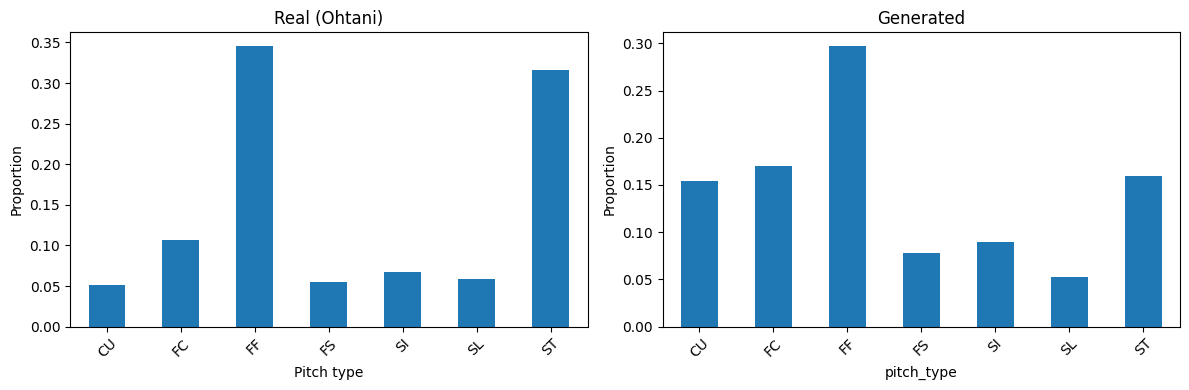

In [5]:
real_mix = df_real["pitch_type"].value_counts(normalize=True).sort_index()
gen_mix = df_gen["pitch_type"].value_counts(normalize=True).sort_index()

mix_df = pd.DataFrame({"Real %": real_mix, "Generated %": gen_mix}).fillna(0)
mix_df.index.name = "Pitch type"
display(mix_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
real_mix.plot(kind="bar", ax=axes[0], title="Real (Ohtani)", ylabel="Proportion", rot=45)
gen_mix.plot(kind="bar", ax=axes[1], title="Generated", ylabel="Proportion", rot=45)
plt.tight_layout()
plt.show()

In [6]:
def speed_summary(df):
    g = df.groupby("pitch_type")["release_speed"]
    return g.agg(["mean", "std"]).round(1)

real_speed = speed_summary(df_real)
gen_speed = speed_summary(df_gen)
real_speed.columns = ["Real mean", "Real std"]
gen_speed.columns = ["Gen mean", "Gen std"]
speed_comp = real_speed.join(gen_speed, how="outer").fillna(0)
speed_comp.index.name = "Pitch type"
display(speed_comp)

,Real mean,Real std,Gen mean,Gen std
Pitch type,,,,
CU,77.0,3.6,82.0,3.9
FC,90.2,3.0,91.6,3.5
FF,97.3,1.9,96.0,3.1
FS,88.7,2.0,88.7,3.2
SI,94.9,2.0,94.6,2.8
SL,86.7,2.4,86.6,2.8
ST,83.9,2.2,83.8,2.9


In [7]:
def spin_summary(df):
    g = df.groupby("pitch_type")["release_spin_rate"]
    return g.agg(["mean", "std"]).round(0)

real_spin = spin_summary(df_real)
gen_spin = spin_summary(df_gen)
real_spin.columns = ["Real mean", "Real std"]
gen_spin.columns = ["Gen mean", "Gen std"]
spin_comp = real_spin.join(gen_spin, how="outer").fillna(0)
spin_comp.index.name = "Pitch type"
display(spin_comp)

,Real mean,Real std,Gen mean,Gen std
Pitch type,,,,
CU,2547.0,162.0,2756.0,125.0
FC,2390.0,130.0,2522.0,101.0
FF,2322.0,145.0,2427.0,99.0
FS,1309.0,254.0,1454.0,187.0
SI,2027.0,291.0,2278.0,101.0
SL,2494.0,119.0,2473.0,104.0
ST,2516.0,142.0,2614.0,111.0


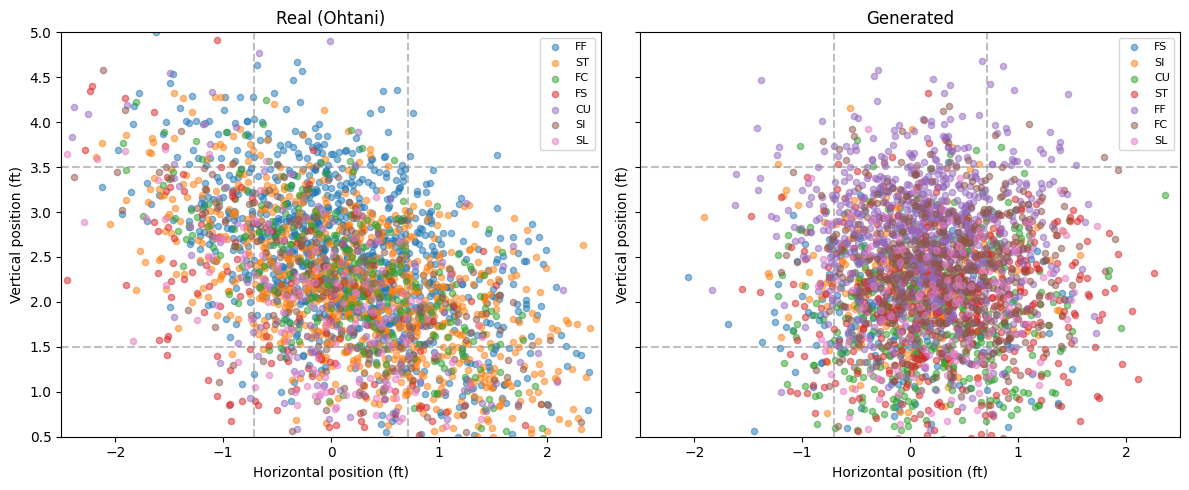

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for pt in df_real["pitch_type"].unique():
    sub = df_real[df_real["pitch_type"] == pt]
    axes[0].scatter(sub["plate_x"], sub["plate_z"], label=pt, alpha=0.5, s=20)
axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(0.5, 5)
axes[0].axhline(1.5, color="gray", linestyle="--", alpha=0.5)
axes[0].axhline(3.5, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(-0.71, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(0.71, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Horizontal position (ft)")
axes[0].set_ylabel("Vertical position (ft)")
axes[0].set_title("Real (Ohtani)")
axes[0].legend(loc="upper right", fontsize=8)

for pt in df_gen["pitch_type"].unique():
    sub = df_gen[df_gen["pitch_type"] == pt]
    axes[1].scatter(sub["plate_x"], sub["plate_z"], label=pt, alpha=0.5, s=20)
axes[1].axhline(1.5, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(3.5, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(-0.71, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(0.71, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Horizontal position (ft)")
axes[1].set_ylabel("Vertical position (ft)")
axes[1].set_title("Generated")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
variability_notes = []
for pt in set(real_speed.index) | set(gen_speed.index):
    r_std = real_speed.loc[pt, "Real std"] if pt in real_speed.index else 0
    g_std = gen_speed.loc[pt, "Gen std"] if pt in gen_speed.index else 0
    if r_std > 0 and g_std < 0.5 * r_std:
        variability_notes.append(f"{pt}: Generated speed std ({g_std:.1f}) << real ({r_std:.1f}) — model may under-represent variability.")

for pt in set(real_spin.index) | set(gen_spin.index):
    r_std = real_spin.loc[pt, "Real std"] if pt in real_spin.index else 0
    g_std = gen_spin.loc[pt, "Gen std"] if pt in gen_spin.index else 0
    if r_std > 0 and g_std < 0.5 * r_std:
        variability_notes.append(f"{pt}: Generated spin std ({g_std:.0f}) << real ({r_std:.0f}) — model may under-represent variability.")

for note in variability_notes:
    print(note)
if not variability_notes:
    print("No notable under-representation of variability detected.")

SI: Generated spin std (101) << real (291) — model may under-represent variability.


In [10]:
print("=== Summary ===")
print(f"Real pitches: {len(df_real)} | Generated: {len(df_gen)}")
print(f"Real pitch types: {sorted(df_real['pitch_type'].unique().tolist())}")
print(f"Generated pitch types: {sorted(df_gen['pitch_type'].unique().tolist())}")
if variability_notes:
    print("\nVariability flags:")
    for n in variability_notes:
        print("  -", n)

=== Summary ===
Real pitches: 2830 | Generated: 2830
Real pitch types: ['CU', 'FC', 'FF', 'FS', 'SI', 'SL', 'ST']
Generated pitch types: ['CU', 'FC', 'FF', 'FS', 'SI', 'SL', 'ST']

Variability flags:
  - SI: Generated spin std (101) << real (291) — model may under-represent variability.
